In [28]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import sklearn as sk 
from sklearn.model_selection import train_test_split as TTS
from sklearn.metrics import mean_squared_error as MSE, r2_score as R2

In [4]:
df = pd.read_csv( "SOCR-HeightWeight.csv") 
df.head(5)


,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


In [5]:
df = df.loc[ :3000, ["Height(Inches)" , "Weight(Pounds)"] ] 

In [6]:
df.isna().sum() 

Height(Inches)    0
Weight(Pounds)    0
dtype: int64

In [7]:
df.shape

(3001, 2)

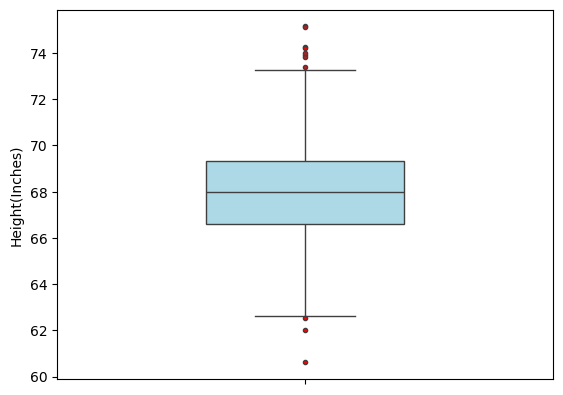

In [8]:
import seaborn as sns

plt.figure( )

sns.boxplot(data=  df.iloc[:,0],  width = 0.4 , 
            boxprops=dict(facecolor='lightblue'), 
            flierprops=dict(marker='o', 
                            markerfacecolor='red',
                            markersize=3),
           )


plt.show() 

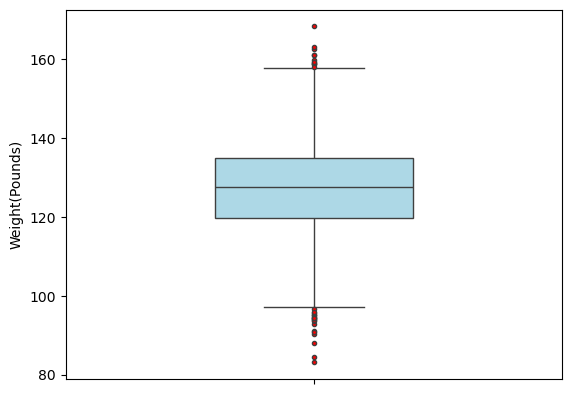

In [9]:
plt.figure( )
sns.boxplot(data=  df.iloc[:,1],  width = 0.4 , 
            boxprops=dict(facecolor='lightblue'), 
            flierprops=dict(marker='o', 
                            markerfacecolor='red',
                            markersize=3),
        )

plt.show() 

In [10]:
df.describe() 

,Height(Inches),Weight(Pounds)
count,3001.000000,3001.000000
mean,68.002732,127.294928
std,1.940371,11.579323
min,60.612650,83.085270
25%,66.611290,119.767100
50%,67.998310,127.471800
75%,69.309570,134.991700
max,75.152800,168.229000


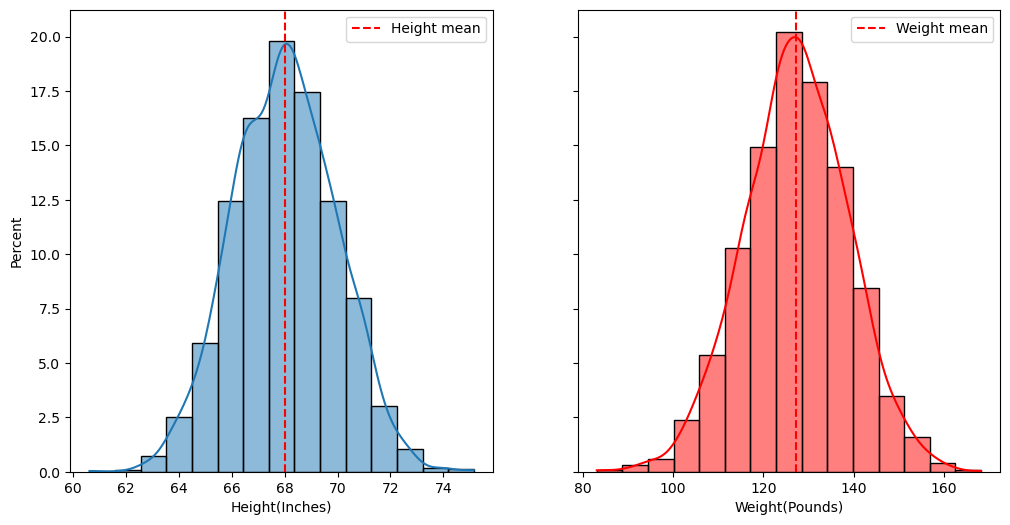

In [11]:
fig, ax = plt.subplots( 1,2 , figsize =(12,6), sharex = False , sharey = True) 

sns.histplot( data =  df.iloc[:,0] , bins = 15, stat= 'percent', kde = True , ax = ax[0])
ax[0].axvline(df.iloc[:, 0].mean(), color='red', linestyle='--', label ='Height mean')
ax[0].legend() 

sns.histplot( data =  df.iloc[:,1] , bins = 15, stat= 'percent', kde = True , ax = ax[1], color = 'red')
ax[1].axvline(df.iloc[:, 1].mean(), color='red', linestyle='--', label ='Weight mean')
ax[1].legend() 

plt.show( )

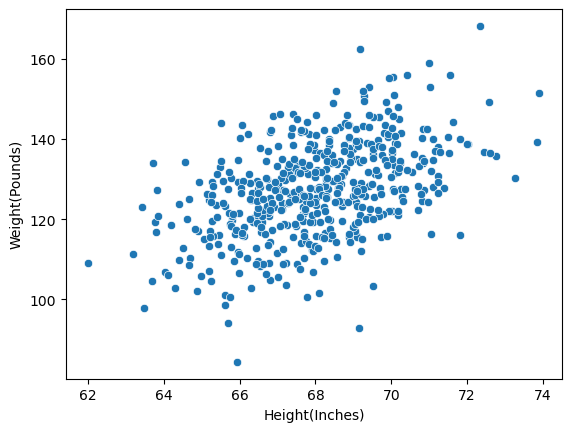

In [12]:
plt.figure() 

sns.scatterplot( data = df , x = df['Height(Inches)'][:500] , y =df['Weight(Pounds)'][:500]) 

plt.show( ) 

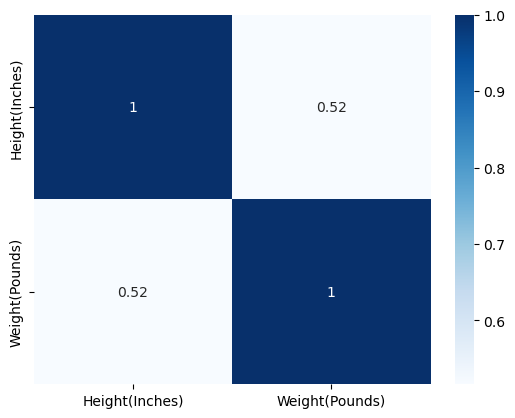

In [13]:
corr = df.corr() 
plt.figure( )
sns.heatmap ( corr , annot=True ,cmap ='Blues') 
plt.show( )

In [14]:
import pandas as pd

df['Height_Group'] = pd.cut(df['Height(Inches)'], bins=[60, 65, 70, 75], labels=['Short', 'Average', 'Tall'])

df['Weight_Group'] = pd.cut(df['Weight(Pounds)'], bins=[100, 130, 160, 190], labels=['Light', 'Medium', 'Heavy'])

cross = pd.crosstab(df['Height_Group'], df['Weight_Group'], normalize=True)
cross


Weight_Group,Light,Medium,Heavy
Height_Group,,,
Short,0.049158,0.004040,0.000000
Average,0.500000,0.285185,0.000673
Tall,0.045118,0.114815,0.001010


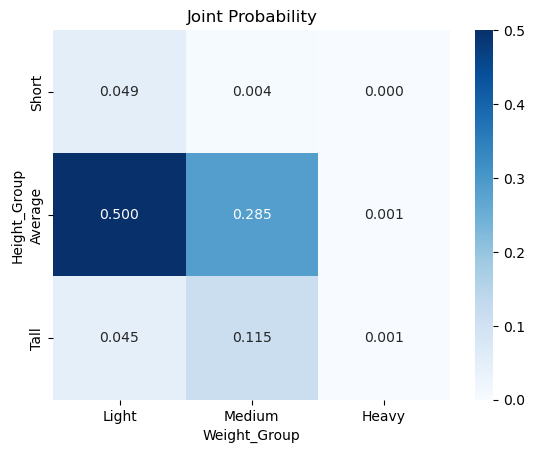

In [15]:
plt.figure() 

sns.heatmap ( cross , cmap = 'Blues',annot= True, linecolor = 'black' ,fmt ='.3f' ) 
plt.title( 'Joint Probability') 
plt.show( )

In [16]:
pd.cut(df['Height(Inches)'], bins=[60, 65, 70, 75], labels=['Short', 'Average', 'Tall']).value_counts()

Height(Inches)
Average    2347
Tall        478
Short       174
Name: count, dtype: int64

In [17]:
df['BMI'] = 703 * (df['Weight(Pounds)'] / (df['Height(Inches)'] ** 2))
df.sample(5)

,Height(Inches),Weight(Pounds),Height_Group,Weight_Group,BMI
1674,69.28403,109.2101,Average,Light,15.993807
2092,64.65639,106.5790,Short,Light,17.922726
2798,66.78698,104.0527,Average,Light,16.399291
706,68.18868,111.4951,Average,Light,16.857243
1518,70.97634,121.2170,Tall,Light,16.915765


In [18]:
df['BMI_Class'] = pd.cut(df['BMI'], bins=[0, 18.5, 24.9, 29.9, 100], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

df.sample(20)

,Height(Inches),Weight(Pounds),Height_Group,Weight_Group,BMI,BMI_Class
733,64.96937,95.70426,Short,NaN,15.939301,Underweight
833,67.44291,123.08040,Average,Light,19.022677,Normal
2230,65.33382,129.76220,Average,Light,21.371127,Normal
127,67.92809,119.30870,Average,Light,18.177269,Underweight
13,67.11656,122.46180,Average,Light,19.111580,Normal
2057,67.28745,112.11970,Average,Light,17.408811,Underweight
1986,63.99095,123.66230,Short,Light,21.230271,Normal
2466,70.26356,154.94080,Tall,Medium,22.062810,Normal
2862,68.26193,117.90400,Average,Light,17.787984,Underweight
231,68.02363,141.10260,Average,Medium,21.437332,Normal


In [19]:
df['BMI_Class'].value_counts() 

BMI_Class
Normal         2150
Underweight     851
Overweight        0
Obese             0
Name: count, dtype: int64

In [20]:
df[df["BMI_Class"] == 'Overweight']

,Height(Inches),Weight(Pounds),Height_Group,Weight_Group,BMI,BMI_Class


In [21]:
model = sk.linear_model.LinearRegression() 

X = df[['Height(Inches)']]   


y = df['Weight(Pounds)']     

model.fit( X, y ) 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
y_hat = model.predict(X) 
df['Model Prediction'] = y_hat
df.head() 

,Height(Inches),Weight(Pounds),Height_Group,Weight_Group,BMI,BMI_Class,Model Prediction
0,65.78331,112.9925,Average,Light,18.355808,Underweight,120.455677
1,71.51521,136.4873,Tall,Medium,18.760773,Normal,138.118793
2,69.39874,153.0269,Average,Medium,22.336747,Normal,131.596792
3,68.21660,142.3354,Average,Medium,21.502458,Normal,127.953973
4,67.78781,144.2971,Average,Medium,22.075458,Normal,126.632637


In [23]:
model.coef_ #Slope

array([3.0815463])

In [24]:
model.intercept_

np.float64(-82.2586381106455)

In [25]:
MSE( y , model.predict(X) ) 

98.29540870710602

In [26]:
R2( y , model.predict(X) ) 

0.26664938624722856

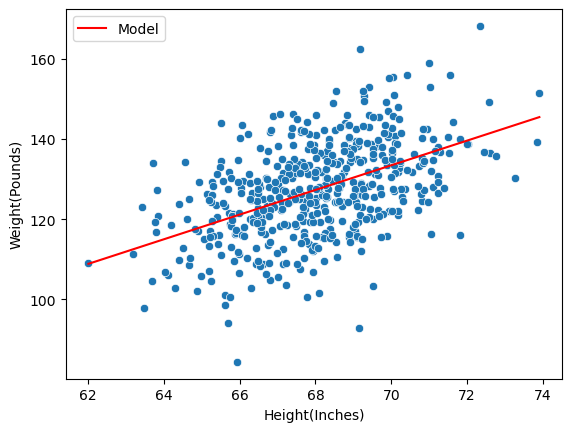

In [27]:
plt.figure() 
idx = np.random.permutation(500)
sns.scatterplot( data = df , x = df['Height(Inches)'][idx] , y =df['Weight(Pounds)'][idx])

sns.lineplot (data = df,  x = df['Height(Inches)'][idx] , y =df['Model Prediction'][idx] , color = 'red', label = 'Model') 
plt.legend() 
plt.show( ) 

(2250, 1) (751, 1) (2250,) (751,)


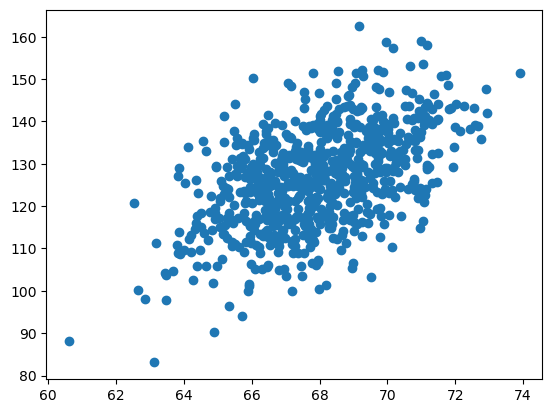

In [37]:
#Now training the lestt data

X_train , X_test, y_train , y_test = TTS(X,y, test_size = 0.25 , random_state=0 , shuffle= True ) 
print( X_train.shape , X_test.shape, y_train.shape , y_test.shape) 
plt.figure() 
plt.scatter( X_test , y_test) 
plt.show( )

In [66]:
#Train the model on the traning set

model.fit(X_train , y_train) 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [67]:
model.coef_  , model.intercept_

(array([3.09031207]), np.float64(-82.76857907082304))

In [68]:
MSE(y_train, model.predict(X_train) ) 

98.0649275660238

In [69]:
R2( y_train , model.predict(X_train) ) 

0.2663445426203278

In [70]:

model.fit( X_test , y_test) 



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [62]:
model.coef_  , model.intercept_

(array([3.05045585]), np.float64(-80.40509977363874))

In [71]:
MSE(y_test, model.predict(X_test) ) 

98.89208044489807

In [72]:
R2( y_test , model.predict(X_test) ) 

0.2667308309035725

In [80]:
#without shuffling , the shuffling is necesarry 
X_train , X_test, y_train , y_test = TTS(X,y, test_size = 0.25 , random_state=3 , shuffle= False ) 

model.fit( X_train , y_train) 


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [81]:
model.coef_ , model.intercept_ 

(array([2.98582351]), np.float64(-75.62489313445104))

In [82]:
R2( X_train , model.predict(X_train)) 

-937.1591141059109

Without shuffling the model failed

# Multiple linear regression

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import load_diabetes
df = load_diabetes( as_frame = True, scaled = False).frame 
df.head(5)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


In [3]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,48.518100,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181,152.133484
std,13.109028,0.499561,4.418122,13.831283,34.608052,30.413081,12.934202,1.290450,0.522391,11.496335,77.093005
min,19.000000,1.000000,18.000000,62.000000,97.000000,41.600000,22.000000,2.000000,3.258100,58.000000,25.000000
25%,38.250000,1.000000,23.200000,84.000000,164.250000,96.050000,40.250000,3.000000,4.276700,83.250000,87.000000
50%,50.000000,1.000000,25.700000,93.000000,186.000000,113.000000,48.000000,4.000000,4.620050,91.000000,140.500000
75%,59.000000,2.000000,29.275000,105.000000,209.750000,134.500000,57.750000,5.000000,4.997200,98.000000,211.500000
max,79.000000,2.000000,42.200000,133.000000,301.000000,242.400000,99.000000,9.090000,6.107000,124.000000,346.000000


In [4]:
df.groupby('sex').mean( )

,age,bmi,bp,s1,s2,s3,s4,s5,s6,target
sex,,,,,,,,,,
1.0,46.382979,26.010638,91.521957,187.995745,111.372340,54.385106,3.668468,4.567993,89.017021,149.021277
2.0,50.942029,26.790338,98.194783,190.439614,120.056039,44.570048,4.526377,4.724760,93.806763,155.666667


In [5]:
df.groupby('sex').std( )

,age,bmi,bp,s1,s2,s3,s4,s5,s6,target
sex,,,,,,,,,,
1.0,13.120665,4.571242,14.125498,33.245204,29.062284,12.966986,1.167182,0.513539,11.403241,75.905781
2.0,12.697623,4.210251,12.613532,36.130091,31.311630,10.755160,1.274462,0.521059,11.089283,78.453313


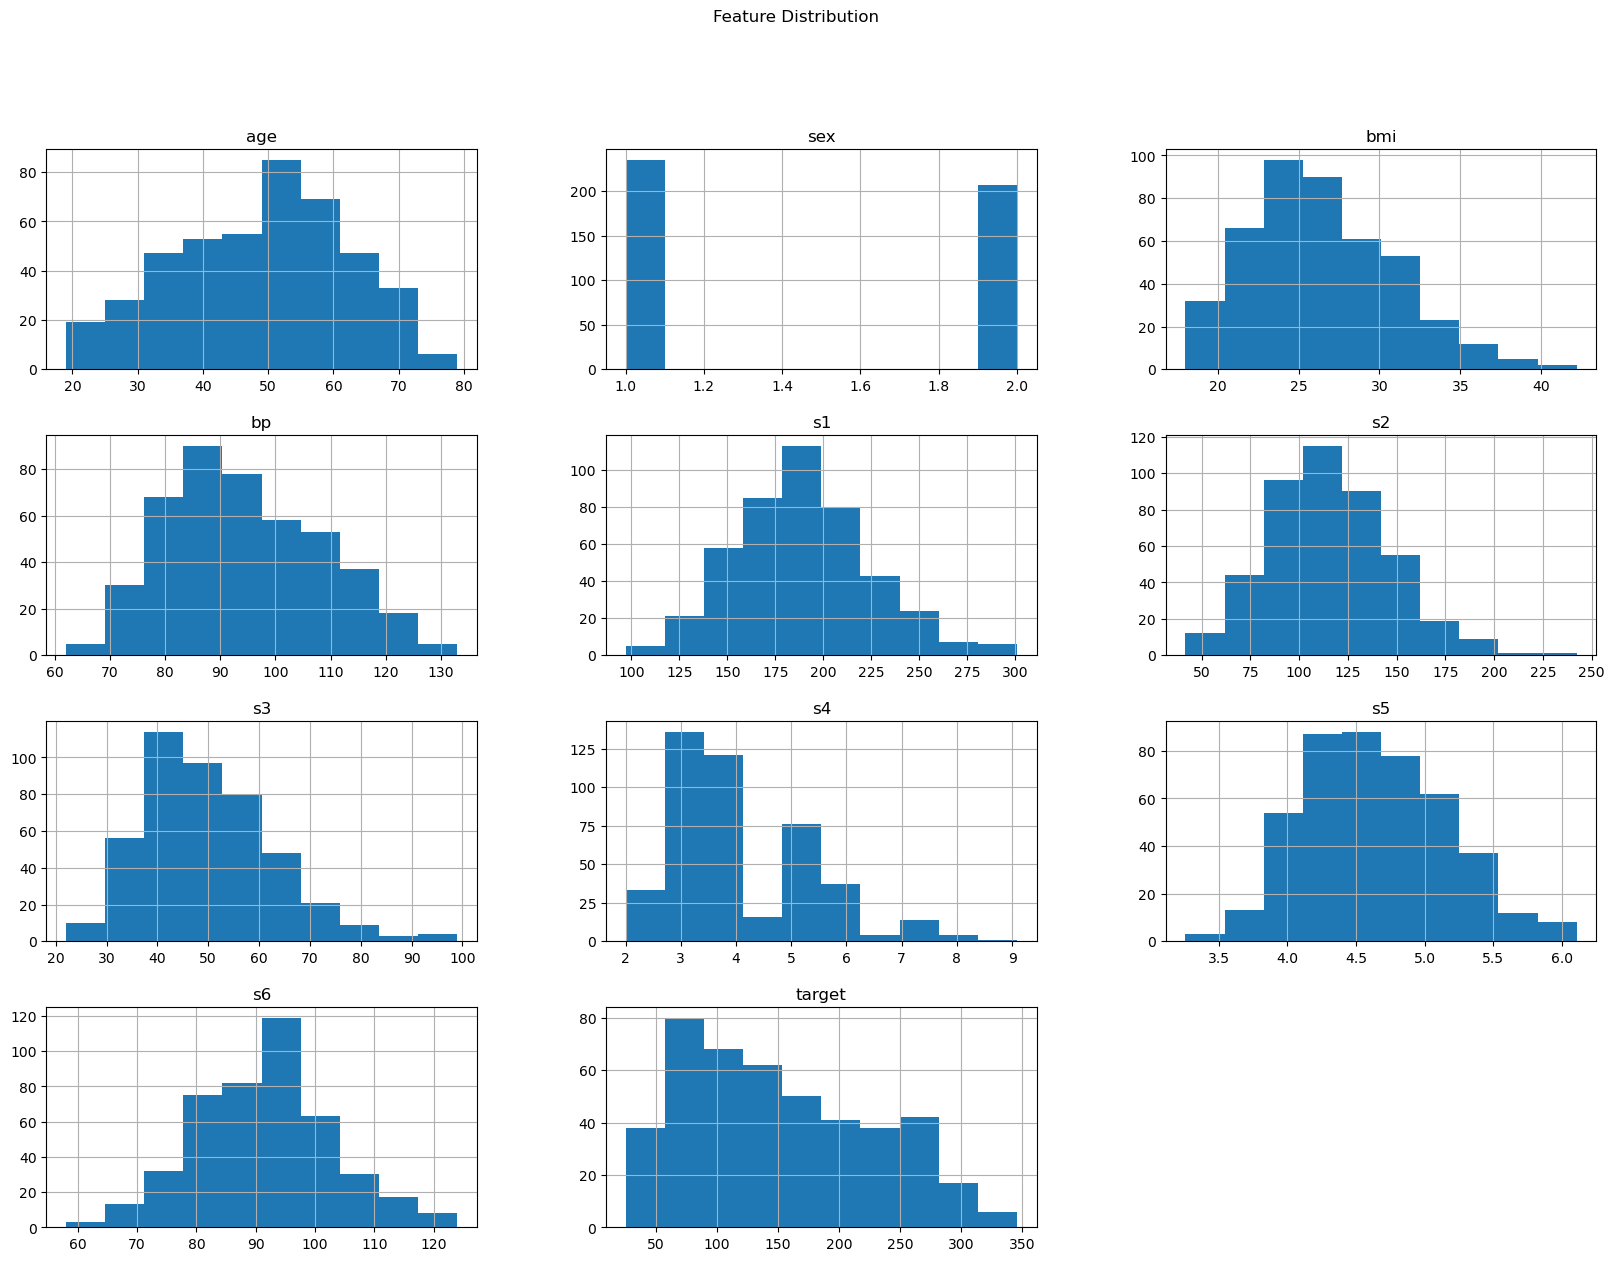

In [6]:
df.hist( figsize=(20,14)  )
plt.suptitle('Feature Distribution')
plt.show( )

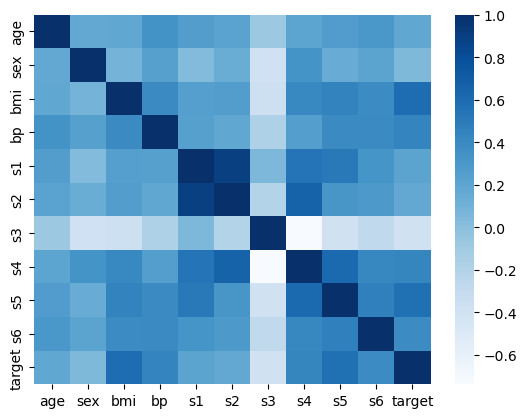

In [7]:
corr = df.corr() 

sns.heatmap( corr , cmap = 'Blues') 
plt.show( )

In [8]:
corr['target'].sort_values(ascending = False) 

target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64

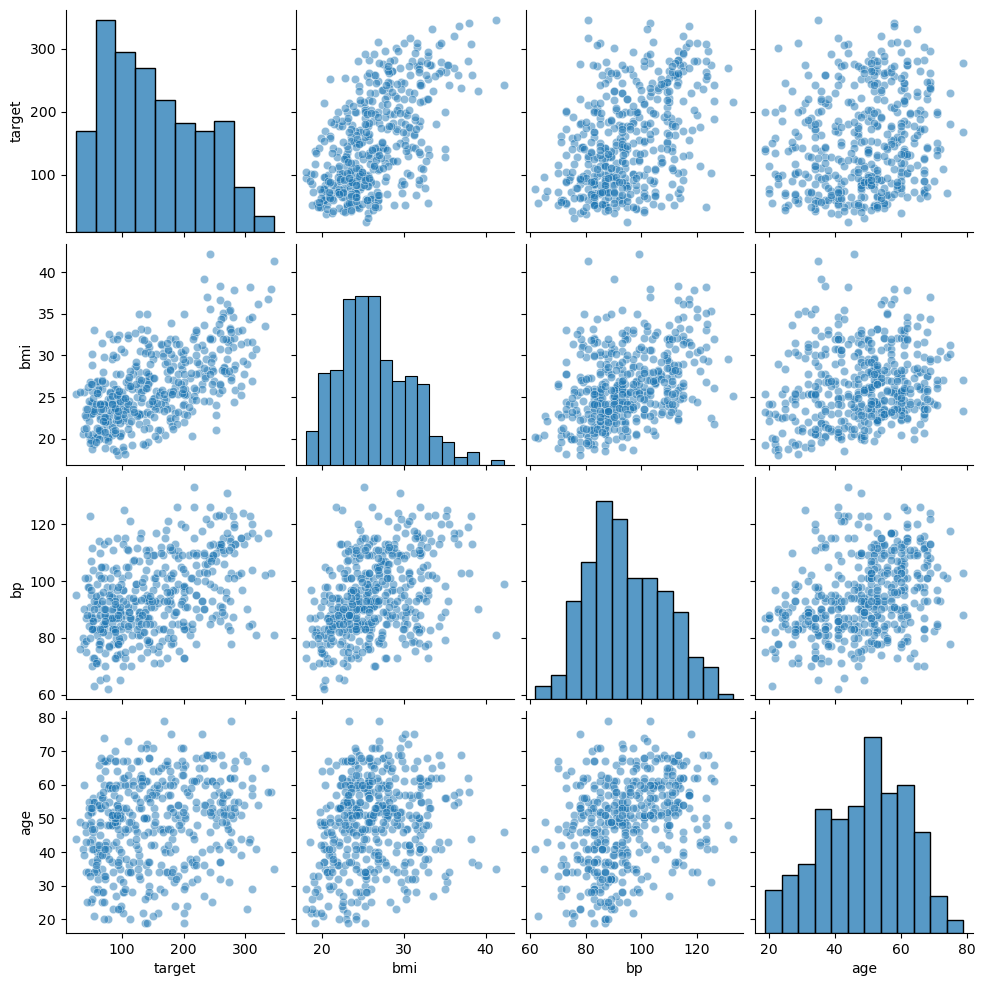

In [9]:
sns.pairplot ( df [ ['target' ,'bmi' , 'bp' , 'age'  ]] , plot_kws={'alpha': 0.5} ) 
plt.show() 

In [10]:
bmi_ = pd.cut( df['bmi'] , bins = [ 0, 18.5, 25, 30 , df['bmi'].max()  ] , labels = ['underweight' , 'good' , 'overweight' , 'obese']) 

target_ = pd.cut( df['target'], bins = [0, 130, 230, df['target'].max() ],
                  labels =  ['low_progression', 'medium_progression', 'high_progression' ] 
                )

cross = pd.crosstab( bmi_ , target_) 
cross
                  
                                       

target,low_progression,medium_progression,high_progression
bmi,,,
underweight,3,0,0
good,130,51,6
overweight,55,65,37
obese,14,34,47


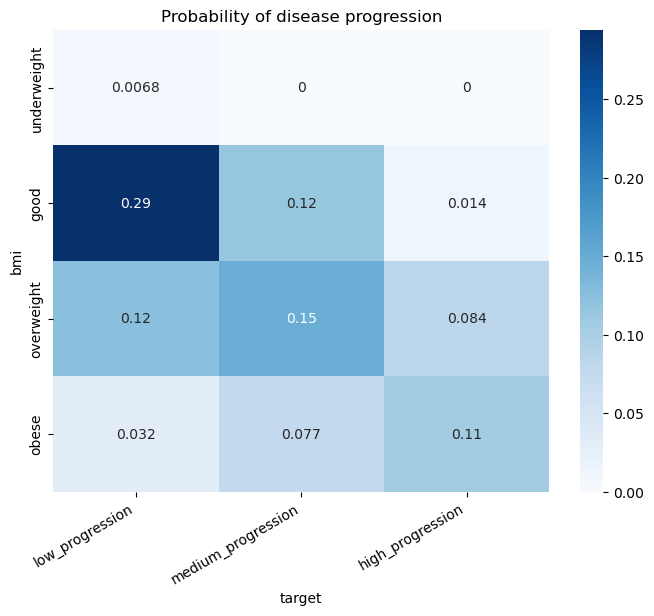

In [11]:
cross = pd.crosstab( bmi_ , target_ , normalize = True)
plt.figure( figsize =(8,6))
sns.heatmap( cross, annot = True , cmap  = 'Blues') 
plt.title( 'Probability of disease progression' ) 
plt.xticks(rotation=30, ha='right')
plt.show() 

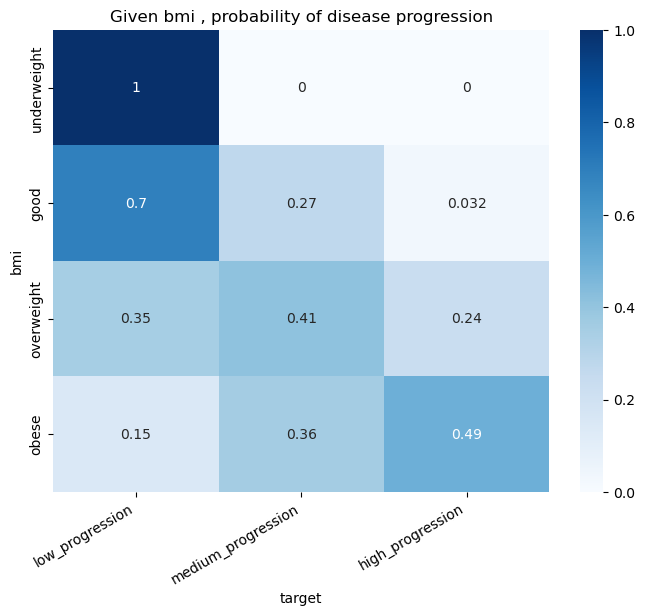

In [12]:
cross = pd.crosstab( bmi_ , target_ , normalize = 'index')
plt.figure( figsize =(8,6))
sns.heatmap( cross, annot = True , cmap  = 'Blues') 
plt.title( 'Given bmi , probability of disease progression' ) 
plt.xticks(rotation=30, ha='right')
plt.show() 

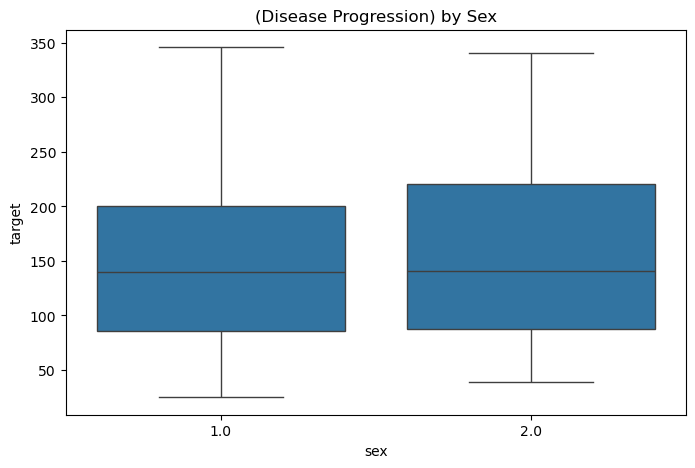

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='sex', y='target', data=df)
plt.title('(Disease Progression) by Sex')
plt.show()

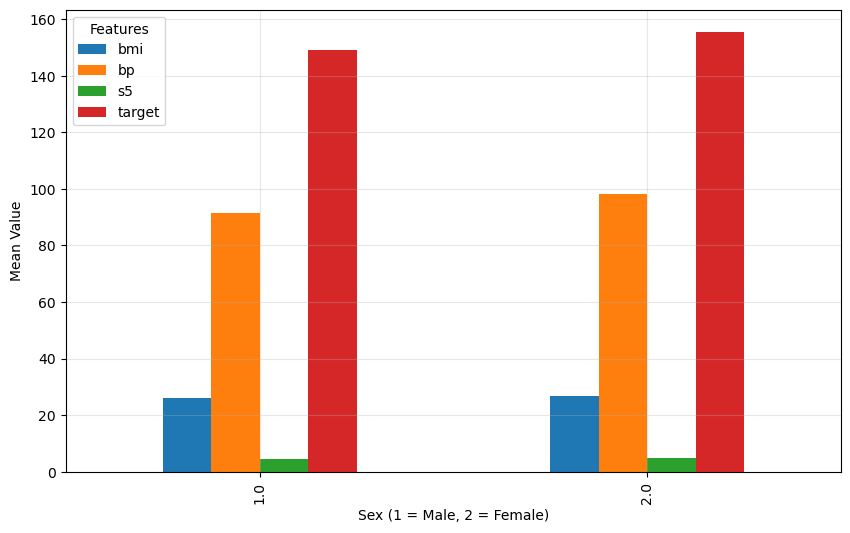

In [14]:
cols = ['bmi', 'bp', 's5', 'target']
grouped = df.groupby('sex')[cols].mean()
grouped.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Sex (1 = Male, 2 = Female)')
plt.ylabel('Mean Value')
plt.legend(title='Features')
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
corr['s1'].sort_values() 

sex       0.035277
s3        0.051519
target    0.212022
bp        0.242464
bmi       0.249777
age       0.260061
s6        0.325717
s5        0.515503
s4        0.542207
s2        0.896663
s1        1.000000
Name: s1, dtype: float64

The s2 can be removed as they are very correlated

## Training on fullset 

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer


numeric = ['age', 'bmi', 'bp', 's1', 's3', 's4', 's5', 's6']
cat = ['sex']

preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), numeric),
    ('onehot', OneHotEncoder(sparse_output=False, drop = 'first'), cat)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=26, shuffle = True )



In [17]:
pipeline.fit( X , y ) 
y_hat = pipeline.predict( X )

df['Prediction'] = y_hat

df.sample(5) 

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target,Prediction
323,68.0,2.0,25.7,109.00,233.0,112.6,35.0,7.00,6.0568,105.0,248.0,233.711386
417,34.0,1.0,33.0,73.00,178.0,114.6,51.0,3.49,4.1271,92.0,55.0,151.638801
84,49.0,1.0,22.7,65.33,168.0,96.2,62.0,2.71,3.8918,60.0,65.0,57.291964
324,57.0,1.0,26.9,98.00,246.0,165.2,38.0,7.00,5.3660,96.0,249.0,209.309623
143,40.0,1.0,26.9,92.00,203.0,119.8,70.0,3.00,4.1897,81.0,60.0,118.457742


In [18]:
r2_score (y , y_hat) 

0.5155359375990978

In [19]:
root_mean_squared_error( y, y_hat ) 

53.59865788176939

## Training and testing

In [20]:
pipeline.fit( X_train , y_train) 
y_hat1 = pipeline.predict( X_train ) 
y_hat2 = pipeline.predict( X_test ) 

print( r2_score ( y_train , y_hat1 ) , r2_score ( y_test, y_hat2)  )

0.5339439559010299 0.4129752184692258


Model is slightly overfitting

In [21]:
print( root_mean_squared_error ( y_train , y_hat1 ) , root_mean_squared_error ( y_test, y_hat2)  )

53.59763773668926 54.09966537097123


In [22]:
new_patient = pd.DataFrame([{
    'age': 55,
    'bmi': 28.5,
    'bp': 95,
    's1': 180,
    's3': 45,
    's4': 4.5,
    's5': 4.8,
    's6': 90,
    'sex': 2
}])

pipeline.predict(new_patient)

array([170.60144876])

Can add regularization to reduce overfitting

In [23]:
from sklearn.linear_model import Ridge

In [24]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha = 2))
])


pipeline.fit( X_train , y_train) 

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...), ('onehot', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [25]:
y_hat = pipeline.predict( X_test ) 
print( r2_score(y_test, y_hat) )

0.4132243996886181


In [26]:
y_hat2 = pipeline.predict( X_train) 
r2_score(y_train , y_hat2) 

0.5339170479529172

## Validation

How well the model behaves on unseen data by splitting the training set and averaging them 

In [27]:
from sklearn.model_selection import cross_val_score 

In [28]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])


scores = cross_val_score(pipeline, X_train , y_train, cv = 5 , scoring = 'r2'  ) 
scores

array([0.54668038, 0.54794144, 0.55157055, 0.38840403, 0.39221384])

In [29]:
scores.mean() , scores.std() 

(np.float64(0.4853620482118365), np.float64(0.07763649973384937))

On average the model score would around 0.4 on test_set and unseen data

In [30]:
from sklearn.linear_model import Lasso

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha  = 3))
])

scores = cross_val_score( pipeline, X_train , y_train, cv = 5 ) 
scores

array([0.51007582, 0.52338284, 0.56286789, 0.35300498, 0.40797328])

In [31]:
scores.mean() 

np.float64(0.4714609630978914)

## Hyperparameter tuning + cross validation

GridSearchCV Finds the hyperparameter using cross validation


In [32]:
from sklearn.model_selection import GridSearchCV
pipeline = Pipeline ( [
    ( 'preprocessor' , preprocessor ) , 
    ( 'model' , Lasso () ) 
])

param_grid = { 'model__alpha': [0.1,0.5,1,5] ,
               'model__max_iter' : [100,500] 
             } #Because model is inside the pipeline __  is necessayr and also the hyper names even if without pipelines


# grid = GridSearchCV (
               

grid_search = GridSearchCV(pipeline, param_grid, scoring ='r2' , cv = 5 , return_train_score=True)

In [33]:
grid_search.fit( X_train , y_train) 

,estimator,"Pipeline(step...l', Lasso())])"
,param_grid,"{'model__alpha': [0.1, 0.5, ...], 'model__max_iter': [100, 500]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('scaler', ...), ('onehot', ...)]"


In [34]:
grid_search.best_params_

{'model__alpha': 0.1, 'model__max_iter': 100}

In [35]:
grid_search.best_score_

np.float64(0.48532245772287463)

In [43]:
import pandas as pd

results = pd.DataFrame(grid_search.cv_results_)
useful_cols = [
    'params',
    'mean_train_score',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]

results[useful_cols].sort_values('rank_test_score')

,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,"{'model__alpha': 0.1, 'model__max_iter': 100}",0.536259,0.485322,0.077552,1
1,"{'model__alpha': 0.1, 'model__max_iter': 500}",0.536259,0.485322,0.077552,1
2,"{'model__alpha': 0.5, 'model__max_iter': 100}",0.535443,0.484529,0.077514,3
3,"{'model__alpha': 0.5, 'model__max_iter': 500}",0.535443,0.484529,0.077514,3
4,"{'model__alpha': 1, 'model__max_iter': 100}",0.533227,0.482660,0.078456,5
5,"{'model__alpha': 1, 'model__max_iter': 500}",0.533227,0.482660,0.078456,5
6,"{'model__alpha': 5, 'model__max_iter': 100}",0.506629,0.465489,0.076775,7
7,"{'model__alpha': 5, 'model__max_iter': 500}",0.506629,0.465489,0.076775,7


In [38]:
print(grid_search.best_estimator_)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('scaler', StandardScaler(),
                                                  ['age', 'bmi', 'bp', 's1',
                                                   's3', 's4', 's5', 's6']),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['sex'])])),
                ('model', Lasso(alpha=0.1, max_iter=100))])


In [47]:
grid_search.best_estimator_.named_steps['model'].coef_

array([  0.37499952,  28.10924495,  14.50701126, -11.8336536 ,
        -6.80305434,   6.95057922,  25.53939867,   2.71512055,
       -19.14602292])

In [48]:
grid_search.feature_names_in_

array(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'],
      dtype=object)

In [50]:
final_model = grid_search.best_estimator_
final_model.predict( new_patient) 

array([170.56563965])